<a href="https://colab.research.google.com/github/Omar-RojasGBF/lis5693/blob/main/Final-Project/Project_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [3]:
import requests
import io

url = "https://raw.githubusercontent.com/Omar-RojasGBF/lis5693/refs/heads/main/Final-Project/ufo_sightings.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

I imported the "UFO Sightings around the world" dataset.

In [4]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head())

          date_time             city_area state country ufo_shape  \
0  10/10/1949 20:30            san marcos    tx      us  cylinder   
1  10/10/1949 21:00          lackland afb    tx     NaN     light   
2  10/10/1955 17:00  chester (uk/england)   NaN      gb    circle   
3  10/10/1956 21:00                  edna    tx      us    circle   
4  10/10/1960 20:00               kaneohe    hi      us     light   

   encounter_length described_encounter_length  \
0            2700.0                 45 minutes   
1            7200.0                    1-2 hrs   
2              20.0                 20 seconds   
3              20.0                   1/2 hour   
4             900.0                 15 minutes   

                                         description date_documented  \
0  This event took place in early fall around 194...       4/27/2004   
1  1949 Lackland AFB&#44 TX.  Lights racing acros...      12/16/2005   
2  Green/Orange circular disc over Chester&#44 En...       1/21/2008

The dataset was saved as a DataFrame with a pandas DataFrame.

In [6]:
features = df['description']
target = df['country']

My features will be the 'description', and my target will be 'country'. If we can examine which types of characteristics the UFOs have in different regions of the world, then governments could have a better change of predicting where certain UFOs will appear.

However, for simplicity, we will focus on Canada and the United States, since most of the reports mention these two countries. The terms "light" and "bright" are mentioned the most in the descriptions from these two nations as well.

In [7]:
target_names = {
    'bright' : 'ca',
    'light' : 'us',
              }

**Split Data into Training and Test Sets**

---



In [8]:
from sklearn.model_selection import train_test_split

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# Drop rows where 'target' (country) is NaN
df_cleaned = df.dropna(subset=['country'])
features_cleaned = df_cleaned['description']
target_cleaned = df_cleaned['country']

X_train, X_test, y_train, y_test = train_test_split(features_cleaned, target_cleaned, test_size=0.2, random_state=42)


print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))


X_train = X_train.fillna('')
X_test = X_test.fillna('')

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 56529 samples.
Testing set has 14133 samples.
Preprocessing training data...
Preprocessing test data...


I split the data into a test dataset (20%) and a training dataset (80%) randomly in a 80:20 ratio with a finish in text-preprocessing. My y_train contained missing values, so removed the rows with 'NaN' values from the both the feature and target before splitting the data.

In [13]:
y_test.unique()

array(['us', 'gb', 'ca', 'de', 'au'], dtype=object)

**Comparing Classifiers **

---



In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr")
ada_classifier = AdaBoostClassifier()
random_classifier = RandomForestClassifier()

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

print("Training Adaboost classifier...")
ada_classifier.fit(train_preprocessed, y_train)

print("Training Random Forest classifier...")
random_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Adaboost classifier...
Training Random Forest classifier...


RandomForestClassifier()

Five different classifiers were ran on the dataset to see which one performs best on evaluation metrics of accuracy, recall, precision, and f1 score.

In [15]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)
ada_predictions = ada_classifier.predict(test_preprocessed)
random_predictions = random_classifier.predict(test_preprocessed)

In [16]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("ADA Accuracy:", np.mean(ada_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.9213896554164013
SVM Accuracy: 0.9375221113705512
LR Accuracy: 0.9311540366518078
ADA Accuracy: 0.9225217575886224
RF Accuracy: 0.9347626123257624


The results indicate that almost all of these have a good performance of accuracy. However, if we were going by the highest number on the thousandths place, then the SVM classifier performed the best, with a 94.4% accuracy.

In [19]:
from sklearn.metrics import classification_report

report_labels = ['ca', 'us']

report_display_names = ['bright', 'light']

print(classification_report(y_test, nb_predictions, labels=report_labels, target_names=report_display_names))
print(classification_report(y_test, lr_predictions, labels=report_labels, target_names=report_display_names))
print(classification_report(y_test, ada_predictions, labels=report_labels, target_names=report_display_names))
print(classification_report(y_test, random_predictions, labels=report_labels, target_names=report_display_names))

              precision    recall  f1-score   support

      bright       0.89      0.01      0.03       593
       light       0.92      1.00      0.96     13014

   micro avg       0.92      0.96      0.94     13607
   macro avg       0.91      0.51      0.49     13607
weighted avg       0.92      0.96      0.92     13607

              precision    recall  f1-score   support

      bright       0.91      0.13      0.23       593
       light       0.93      1.00      0.96     13014

   micro avg       0.93      0.96      0.95     13607
   macro avg       0.92      0.56      0.60     13607
weighted avg       0.93      0.96      0.93     13607

              precision    recall  f1-score   support

      bright       0.83      0.05      0.10       593
       light       0.92      1.00      0.96     13014

   micro avg       0.92      0.96      0.94     13607
   macro avg       0.88      0.53      0.53     13607
weighted avg       0.92      0.96      0.92     13607

              preci

I ran a classification report for all five classifiers. I had tell the 'classification_report' to only consider 'ca' and 'us' since I have five unique country classes in my data. 'ca' was named 'bright' and 'us' was named 'light'.

In [20]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': np.logspace(0, 3, 10)}
parameters = {'C': [0.1, 1, 10, 100, 1000]}

print("Grid search for SVM")
svm_best = GridSearchCV(svm_classifier, parameters, cv=10, verbose=1)
svm_best.fit(train_preprocessed, y_train)

Grid search for SVM
Fitting 10 folds for each of 5 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

GridSearchCV(cv=10, estimator=LinearSVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000]}, verbose=1)

For the classification report for the Support Vector Machine classifier, I used the code line 51-54.
10 folds for each of 5 candidates were fitted, which totaled 50 fits.

In [21]:
print("Best SVM Parameters")
print(svm_best.best_params_)

Best SVM Parameters
{'C': 1}


In [22]:
best_svm_predictions = svm_best.predict(test_preprocessed)

print("Best SVM Accuracy:", np.mean(best_svm_predictions == y_test))

Best SVM Accuracy: 0.9375221113705512


In [25]:
from sklearn.metrics import classification_report, confusion_matrix

report_labels = ['ca', 'us']

report_display_names = ['bright', 'light']

print(classification_report(y_test, svm_predictions, labels=report_labels, target_names=report_display_names))

              precision    recall  f1-score   support

      bright       0.87      0.23      0.36       593
       light       0.94      1.00      0.97     13014

   micro avg       0.94      0.96      0.95     13607
   macro avg       0.90      0.61      0.66     13607
weighted avg       0.94      0.96      0.94     13607



I had to adjust the code in the same way I did for the classification report of all five classifiers due to my country classes. Based on all the evaluation metrics, it appears that Support Vector Machine performed the best.

(array([0.5, 1.5]), [Text(0.5, 0, 'bright'), Text(1.5, 0, 'light')])

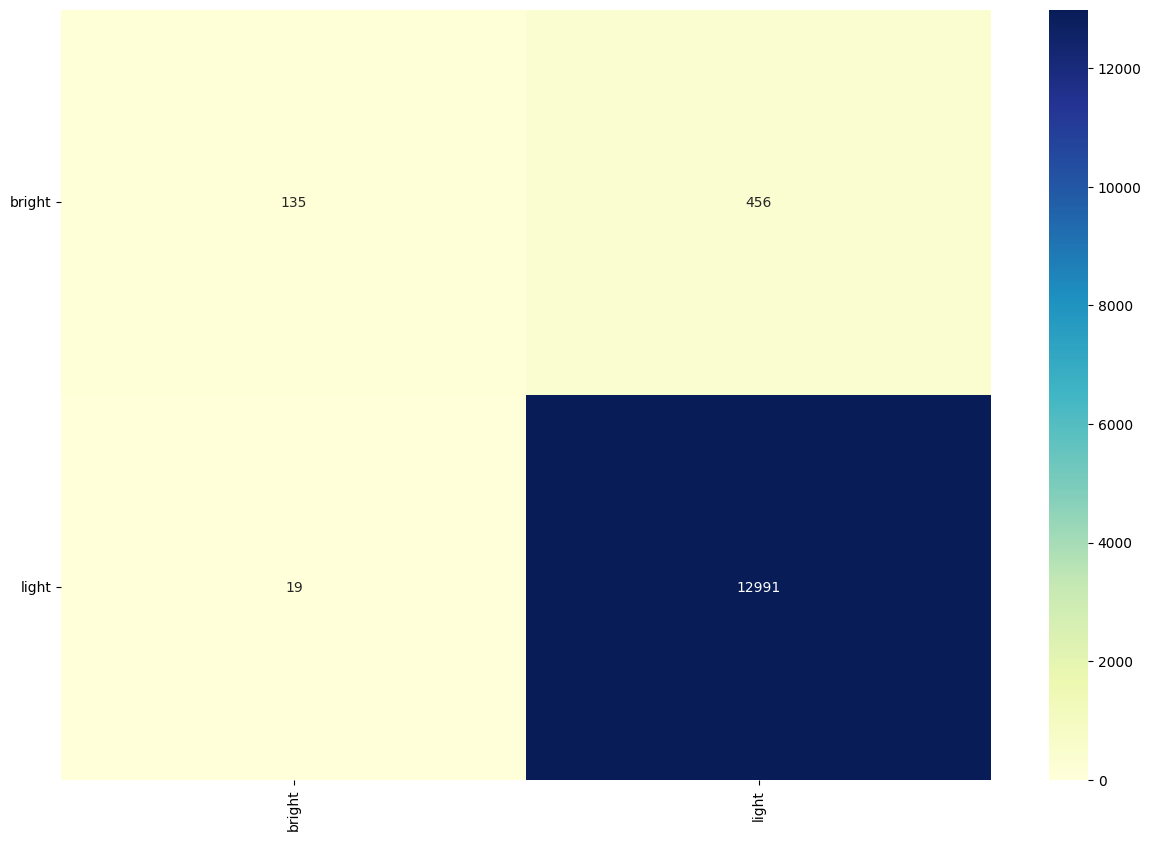

In [29]:
%matplotlib inline
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

report_labels_for_matrix = ['ca', 'us']

report_display_names_for_matrix = ['bright', 'light']

conf_matrix = confusion_matrix(y_test, svm_predictions, labels=report_labels_for_matrix)
conf_matrix_df = pd.DataFrame(conf_matrix, index=report_display_names_for_matrix, columns=report_display_names_for_matrix)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)

A visual for the confusion matrix is made with the SVM classifier. Again, my country classes had to be clarified for the code. The model correctly classified 135 descriptions with the word "bright" as taking place in Canada, with only 19 misclassified. The model also correctly classified 12991 descriptions with the word "light" as taking place in the United States, with only 456 misclassified.

**Supervised Machine Learning **

---



In [30]:
url = "https://raw.githubusercontent.com/Omar-RojasGBF/lis5693/refs/heads/main/Final-Project/ufo_sightings.csv"
response = requests.get(url)
response.raise_for_status()
raw_csv_data = response.text

new_data = pd.read_csv(io.StringIO(raw_csv_data))
print(new_data.head())

          date_time             city_area state country ufo_shape  \
0  10/10/1949 20:30            san marcos    tx      us  cylinder   
1  10/10/1949 21:00          lackland afb    tx     NaN     light   
2  10/10/1955 17:00  chester (uk/england)   NaN      gb    circle   
3  10/10/1956 21:00                  edna    tx      us    circle   
4  10/10/1960 20:00               kaneohe    hi      us     light   

   encounter_length described_encounter_length  \
0            2700.0                 45 minutes   
1            7200.0                    1-2 hrs   
2              20.0                 20 seconds   
3              20.0                   1/2 hour   
4             900.0                 15 minutes   

                                         description date_documented  \
0  This event took place in early fall around 194...       4/27/2004   
1  1949 Lackland AFB&#44 TX.  Lights racing acros...      12/16/2005   
2  Green/Orange circular disc over Chester&#44 En...       1/21/2008

Supervised Machine Learning is used to make predictions of the data.

In [31]:
text = new_data['description']

In [32]:
text

,description
0,This event took place in early fall around 194...
1,1949 Lackland AFB&#44 TX. Lights racing acros...
2,Green/Orange circular disc over Chester&#44 En...
3,My older brother and twin sister were leaving ...
4,AS a Marine 1st Lt. flying an FJ4B fighter/att...
...,...
80327,Round from the distance/slowly changing colors...
80328,Boise&#44 ID&#44 spherical&#44 20 min&#44 10 r...
80329,Napa UFO&#44
80330,Saw a five gold lit cicular craft moving fastl...


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [34]:
vect = TfidfVectorizer(stop_words = 'english').fit(X_train)
dtm = vect.fit_transform(X_train)

Text Preprocessing is done here

**Predicting Features: Fitting New Dataset **

---



In [37]:
from sklearn.svm import LinearSVC
model = LinearSVC()
classif = model.fit(dtm, y_train)

I used the LinearSVC Classifier to make predictions based on the previously trained machine learning model.

In [41]:
test_dtm = vect.transform(new_data['description'].fillna(''))

I preprocessed the 'description' column from the 'new_data' dataframe to convert it into that same format that the data model was trained on.

There were missing values (NaN) in the 'description' column, so I had to transform the missing values into empty fields.

In [42]:
test = classif.predict(test_dtm)

My prediction is made with the machine learning model for the 'country' of the dataset.

In [49]:
df2 = pd.DataFrame(test)
df2.rename(columns={0: 'country'}, inplace=True)

I rename the columns from 0 -> country

In [50]:
df2

,country
0,us
1,us
2,gb
3,us
4,us
...,...
80327,us
80328,us
80329,us
80330,us


It appears that the original five classes of countries in the dataset are now tagged to each description. However, this is difficult to tell since a majority of the UFO sighting reports are from the United States.

In [51]:
new_data['country'] = df2['country']
combined_df = new_data

I merged the metadata from the new_data file with the 'country' column from df2 into the original file that contains the empty column to reconstruct the complete dataset.

In [52]:
display(combined_df.head())

,date_time,city_area,state,country,ufo_shape,encounter_length,described_encounter_length,description,date_documented,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700.0,45 minutes,This event took place in early fall around 194...,4/27/2004,29.883056,-97.941111
1,10/10/1949 21:00,lackland afb,tx,us,light,7200.0,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.384210,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20.0,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.200000,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20.0,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.978333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900.0,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.418056,-157.803611


In [53]:
combined_df.to_csv('predicted_data.csv', index=False)